## Understanding LSTM Fundamentals

### What is a LSTM?

An LSTM (Long Short-Term Memory) is an advanced form of recurrent neural network that can process sequences of data by maintaining a sophisticated "memory" mechanism with gates to control information flow.

Key Characteristics:

- Sequential Processing: Processes data one time step at a time

- Memory: Maintains cell state and hidden state with gating mechanisms (input, forget, and output gates)

- Parameter Sharing: Uses the same weights across all time steps

- Suitable for: Long sequences (100+ time steps) due to ability to capture long-term dependencies and mitigate vanishing gradient problem

### LSTM Architecture


In [7]:
# Basic LSTM structure
# Input: [batch_size, sequence_length, features]
# Hidden State: [batch_size, hidden_units]
# Cell State: [batch_size, hidden_units]
# Output: [batch_size, output_units]

## Code Implementation

### Change Working directory

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os
os.chdir('/content/drive/MyDrive/DAM202_dataset')
os.listdir()

['weather_data.csv', '.ipynb_checkpoints', 'best_simple_rnn_model.h5']

### 1.1 Installation and Imports

In [11]:
#Install required packages (run in terminal)
!pip install tensorflow pandas numpy matplotlib scikit-learn seaborn

In [12]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras for LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout  # Add LSTM here
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Input

# Data preprocessing tools
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set random seeds for reproducible results
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Setup completed successfully!")


TensorFlow version: 2.19.0
Setup completed successfully!


### 1.2 Data Loading and Exploration

#### 1.2.1  Load Bangladesh Weather Data

In [13]:
def load_weather_data(file_path):
    """
    Load Bangladesh weather data and create proper structure

    Expected CSV format:
    Year, Day, Wind_Speed, Specific_Humidity, Relative_Humidity, Precipitation, Temperature
    Example: 1990, 240, 3.26, 15.62, 65, 0.69, 30.65
    """

    # Load the CSV file
    df = pd.read_csv('weather_data.csv') #Same working directory

    # Define column names based on your data description
    column_names = [
        'Year', 'Day', 'Wind_Speed', 'Specific_Humidity',
        'Relative_Humidity', 'Precipitation', 'Temperature'
    ]

    # Assign column names if they're not already set
    if len(df.columns) == len(column_names):
        df.columns = column_names

    # Create proper date from Year and Day
    df['Date'] = pd.to_datetime(df['Year'] * 1000 + df['Day'], format='%Y%j')

    # Set date as index for time series analysis
    df.set_index('Date', inplace=True)

    # Remove original Year and Day columns
    df.drop(['Year', 'Day'], axis=1, inplace=True)

    print(f"Data loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Date range: {df.index.min()} to {df.index.max()}")

    return df

# Load your data
data_file = "bangladesh_weather_data.csv"  # Replace with your file path
df = load_weather_data(data_file)


Data loaded successfully!
Shape: (12113, 5)
Date range: 1990-01-01 00:00:00 to 2023-03-01 00:00:00


In [14]:
df.head(10)

,Wind_Speed,Specific_Humidity,Relative_Humidity,Precipitation,Temperature
Date,,,,,
1990-01-01,1.08,5.68,53.06,0.0,16.33
1990-01-02,1.13,5.92,58.06,0.0,15.68
1990-01-03,1.33,5.68,52.69,0.0,16.56
1990-01-04,1.09,5.19,47.19,0.0,17.09
1990-01-05,0.94,4.82,42.88,0.0,17.26
1990-01-06,1.14,4.94,43.62,0.0,17.29
1990-01-07,1.04,5.49,46.81,0.0,17.98
1990-01-08,1.06,5.07,44.25,0.0,17.58
1990-01-09,0.85,4.82,42.31,0.0,17.25


In [15]:
#Compare with original dataset
main_df = pd.read_csv('weather_data.csv') #Same working directory
main_df.head()

,Year,Day,Wind Speed,Specific Humidity,Relative Humidity,Precipitation,Temperature
0,1990,1,1.08,5.68,53.06,0.0,16.33
1,1990,2,1.13,5.92,58.06,0.0,15.68
2,1990,3,1.33,5.68,52.69,0.0,16.56
3,1990,4,1.09,5.19,47.19,0.0,17.09
4,1990,5,0.94,4.82,42.88,0.0,17.26


#### 1.2.2 Data Exploration and Visualization

=== BANGLADESH WEATHER DATA EXPLORATION ===
Dataset Shape: (12113, 5)
Date Range: 1990-01-01 to 2023-03-01
Total Days: 12113 days
Years Covered: 34 years

=== BASIC STATISTICS ===
       Wind_Speed  Specific_Humidity  Relative_Humidity  Precipitation  \
count    12113.00           12113.00           12113.00       12113.00   
mean         1.31              15.21              74.64           7.18   
std          0.54               5.53              15.29          13.13   
min          0.44               2.62              15.81           0.00   
25%          0.95               9.95              65.25           0.00   
50%          1.15              16.17              79.62           1.16   
75%          1.52              20.57              86.56           9.26   
max          5.34              24.29              96.12         170.63   

       Temperature  
count     12113.00  
mean         25.04  
std           4.37  
min          11.19  
25%          21.43  
50%          26.93  
75%   

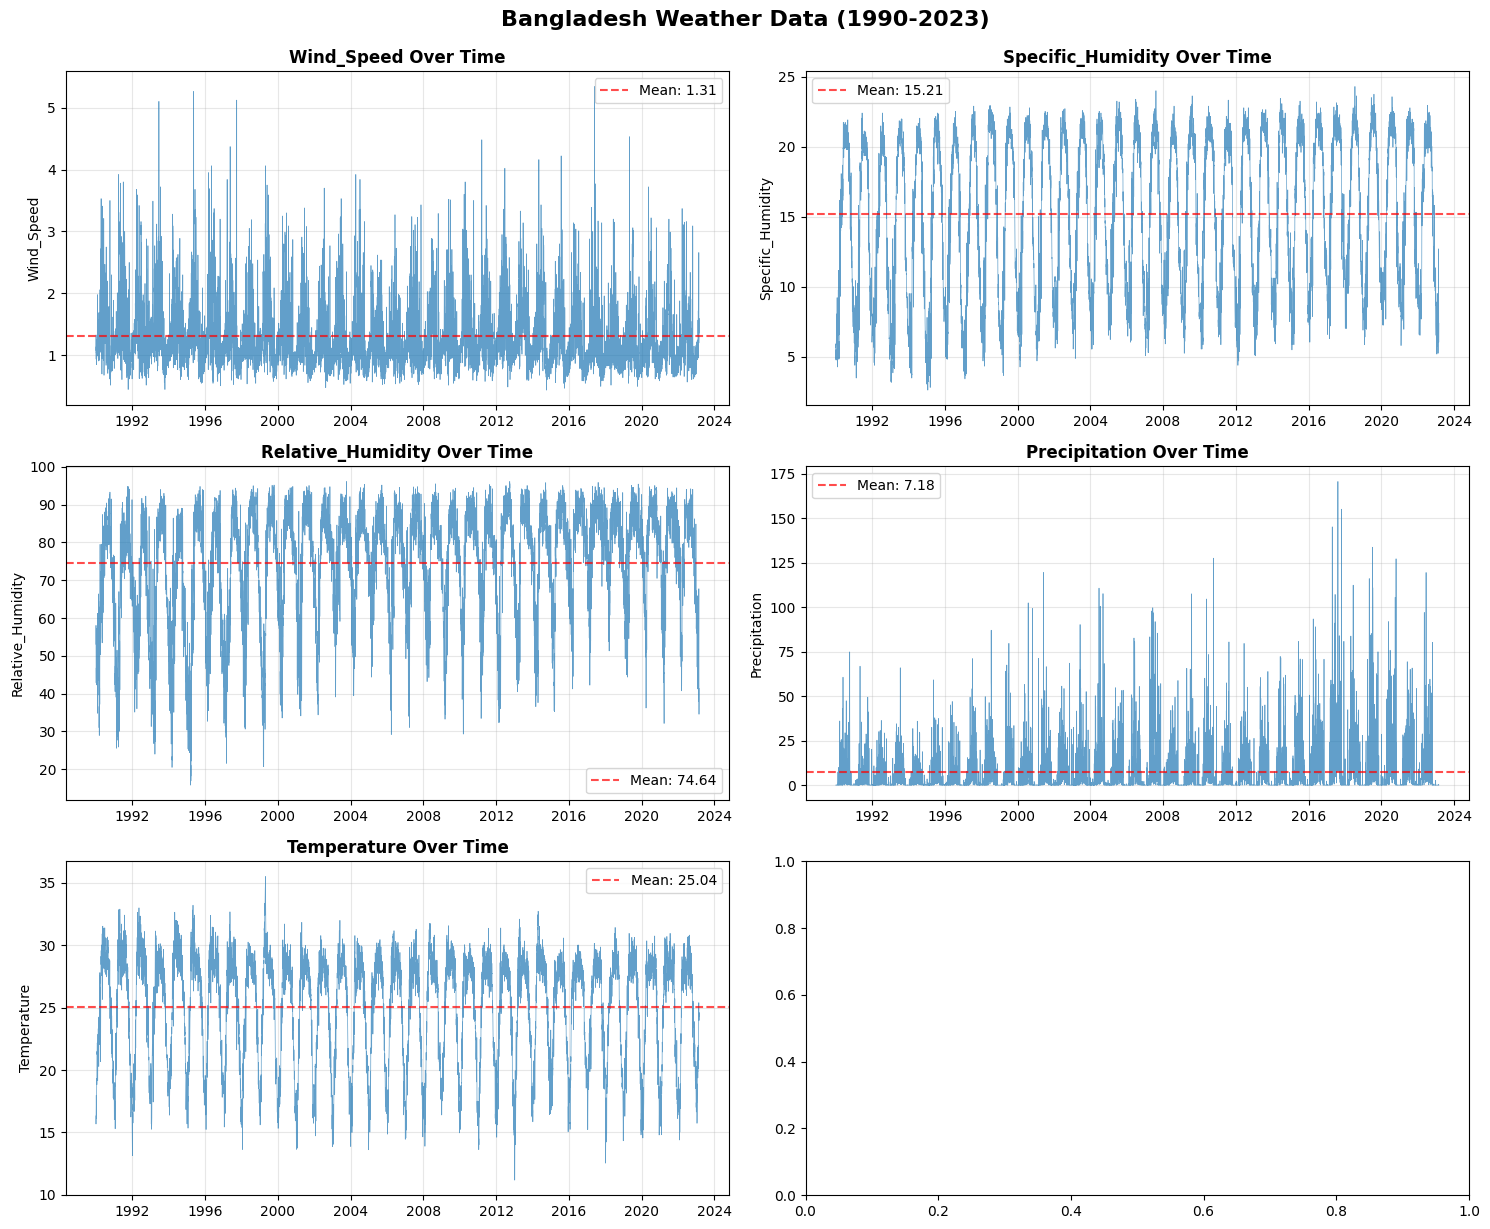

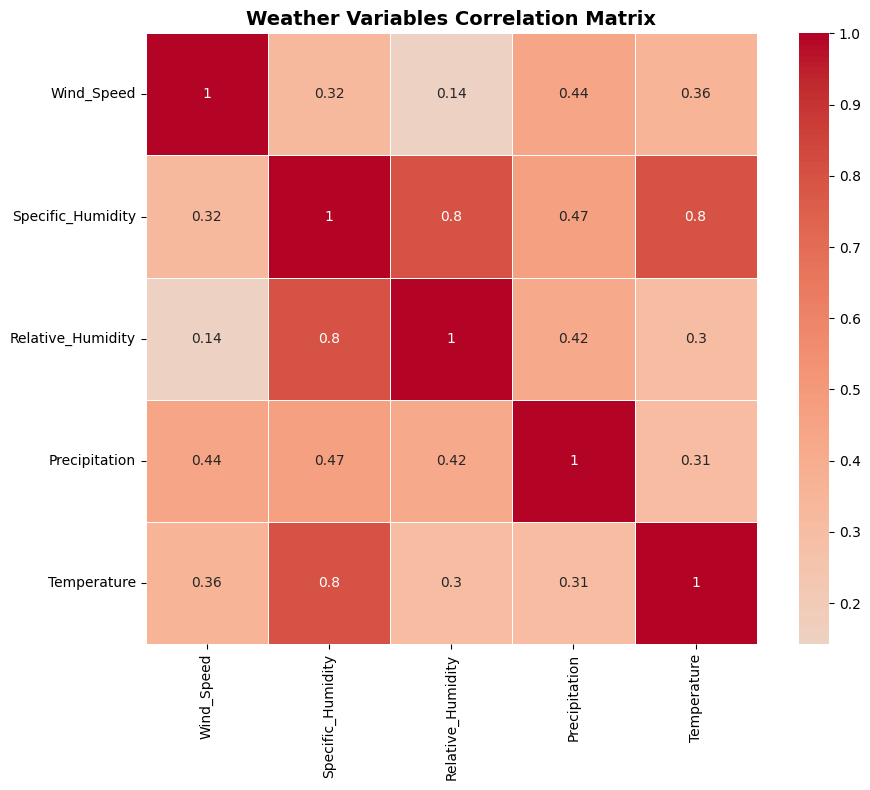

In [16]:
def explore_weather_data(df):
    """
    Comprehensive exploration of weather data
    """

    print("=== BANGLADESH WEATHER DATA EXPLORATION ===")
    print(f"Dataset Shape: {df.shape}")
    print(f"Date Range: {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}")
    print(f"Total Days: {len(df)} days")
    print(f"Years Covered: {df.index.year.nunique()} years")

    # Basic statistics
    print("\n=== BASIC STATISTICS ===")
    print(df.describe().round(2))

    # Check for missing values
    print("\n=== MISSING VALUES ===")
    missing_values = df.isnull().sum()
    print(missing_values)

    # Data types
    print("\n=== DATA TYPES ===")
    print(df.dtypes)

    # Visualize all weather variables
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    axes = axes.flatten()

    for i, column in enumerate(df.columns):
        axes[i].plot(df.index, df[column], alpha=0.7, linewidth=0.5)
        axes[i].set_title(f'{column} Over Time', fontsize=12, fontweight='bold')
        axes[i].set_ylabel(column)
        axes[i].grid(True, alpha=0.3)

        # Add some statistics to the plot
        mean_val = df[column].mean()
        axes[i].axhline(y=mean_val, color='red', linestyle='--', alpha=0.7,
                       label=f'Mean: {mean_val:.2f}')
        axes[i].legend()

    plt.tight_layout()
    plt.suptitle('Bangladesh Weather Data (1990-2023)', fontsize=16, fontweight='bold', y=1.02)
    plt.show()

    # Correlation matrix
    plt.figure(figsize=(10, 8))
    correlation_matrix = df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title('Weather Variables Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return df

# Explore the data
df_explored = explore_weather_data(df)


### 1.3 Data Preprocessing for LSTM

#### 1.3.1 Data Cleaning

In [17]:
def clean_weather_data(df):
    """
    Clean the weather data for LSTM processing (Optimized)
    """

    print("=== DATA CLEANING PROCESS ===")

    # Make a copy to avoid modifying original data
    df_clean = df.copy()

    # 1. Handle missing values
    print(f"Missing values before cleaning: {df_clean.isnull().sum().sum()}")

    # Use newer pandas syntax for fillna
    df_clean = df_clean.ffill().bfill()

    print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")

    # 2. Remove outliers using IQR method (VECTORIZED)
    print("\n=== OUTLIER REMOVAL ===")

    # Calculate Q1, Q3, and IQR for all columns at once
    Q1 = df_clean.quantile(0.25)
    Q3 = df_clean.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers for all columns at once
    outliers_mask = (df_clean < lower_bound) | (df_clean > upper_bound)
    outliers_count = outliers_mask.sum()

    # Clip all columns at once
    df_clean = df_clean.clip(lower=lower_bound, upper=upper_bound, axis=1)

    # Print outlier counts
    for column in outliers_count.index:
        print(f"{column}: {outliers_count[column]} outliers handled")

    # 3. Basic feature engineering for time series
    df_clean['Month'] = df_clean.index.month
    df_clean['Day_of_Year'] = df_clean.index.dayofyear

    # Add simple moving averages (helpful for LSTM)
    df_clean['Temp_MA_3'] = df_clean['Temperature'].rolling(window=3, min_periods=1).mean()
    df_clean['Temp_MA_7'] = df_clean['Temperature'].rolling(window=7, min_periods=1).mean()

    # Remove rows with NaN values created by moving averages
    df_clean.dropna(inplace=True)

    print(f"\nFinal dataset shape: {df_clean.shape}")

    return df_clean

# Clean the data
df_clean = clean_weather_data(df_explored)

=== DATA CLEANING PROCESS ===
Missing values before cleaning: 0
Missing values after cleaning: 0

=== OUTLIER REMOVAL ===
Wind_Speed: 661 outliers handled
Specific_Humidity: 0 outliers handled
Relative_Humidity: 152 outliers handled
Precipitation: 1089 outliers handled
Temperature: 0 outliers handled

Final dataset shape: (12113, 9)


In [18]:
df_clean.head()

,Wind_Speed,Specific_Humidity,Relative_Humidity,Precipitation,Temperature,Month,Day_of_Year,Temp_MA_3,Temp_MA_7
Date,,,,,,,,,
1990-01-01,1.08,5.68,53.06,0.0,16.33,1,1,16.330000,16.330
1990-01-02,1.13,5.92,58.06,0.0,15.68,1,2,16.005000,16.005
1990-01-03,1.33,5.68,52.69,0.0,16.56,1,3,16.190000,16.190
1990-01-04,1.09,5.19,47.19,0.0,17.09,1,4,16.443333,16.415
1990-01-05,0.94,4.82,42.88,0.0,17.26,1,5,16.970000,16.584


#### 1.3.2 Data Normalization (Critical for LSTM)


In [19]:
def normalize_data_for_rnn(df, target_column='Temperature'):
    """
    Normalize data for LSTM training

    Important: We fit the scaler only on training data to prevent data leakage
    """

    print(f"=== DATA NORMALIZATION FOR LSTM ===")
    print(f"Target variable: {target_column}")

    # Separate features and target
    feature_columns = [col for col in df.columns if col != target_column]

    print(f"Feature columns: {feature_columns}")
    print(f"Number of features: {len(feature_columns)}")

    # Initialize scalers
    feature_scaler = MinMaxScaler(feature_range=(0, 1))
    target_scaler = MinMaxScaler(feature_range=(0, 1))

    return df, feature_columns, feature_scaler, target_scaler

# Prepare for normalization
df_processed, feature_columns, feature_scaler, target_scaler = normalize_data_for_rnn(df_clean)

=== DATA NORMALIZATION FOR LSTM ===
Target variable: Temperature
Feature columns: ['Wind_Speed', 'Specific_Humidity', 'Relative_Humidity', 'Precipitation', 'Month', 'Day_of_Year', 'Temp_MA_3', 'Temp_MA_7']
Number of features: 8


In [20]:
df_processed.head(2)

,Wind_Speed,Specific_Humidity,Relative_Humidity,Precipitation,Temperature,Month,Day_of_Year,Temp_MA_3,Temp_MA_7
Date,,,,,,,,,
1990-01-01,1.08,5.68,53.06,0.0,16.33,1,1,16.330,16.330
1990-01-02,1.13,5.92,58.06,0.0,15.68,1,2,16.005,16.005


These lines are for basic feature engineering in time series analysis, which helps a neural network learn patterns better by adding informative features derived from the raw data.

What are these features?
- Month: The month from each date (e.g., January, February, etc.), which helps encode potential seasonal effects (like monsoons or cold seasons).

- Day_of_Year: The position of each date in the year (e.g., 1 for January 1st, 365 for December 31st), which can capture cyclic trends and annual seasonality.

- Temp_MA_3: The average temperature over the past 3 days for each day.

- Temp_MA_7: The average temperature over the past 7 days for each day.

Why are they done?
- Month and Day_of_Year transform raw date information into numerical features so that machine learning models can learn from seasonal patterns (e.g., temperature might be higher in June than in December).

- Moving averages (Temp_MA_3 and Temp_MA_7) smooth the original temperature signal. They reduce noise and short-term fluctuations, making longer-term trends and cycles more visible for the model. These features help the neural network understand not just today's temperature but also recent context, which is important for forecasting.

Why do we do this for time series models?
- Expose Patterns: Weather data shows seasonal/cyclic behaviors; encoding month and day-of-year helps the model pick up on regular patterns.

- Reduce Noise: Moving averages help to "smooth out" outlier values, giving the model a clearer picture of underlying trends.

- Learning Context: LSTMs thrive when they can access recent history and capture long-term dependencies. Including moving averages lets the model access summarized context of the recent past, not just raw daily values, while LSTM's gating mechanisms help retain important information over longer sequences.

#### 1.3.3 Time Series Train-Test Split

In [21]:
def create_time_series_split(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    Create time-aware train/validation/test split for time series

    Important: No shuffling to maintain temporal order!
    """

    print(f"=== TIME SERIES DATA SPLITTING ===")

    n_samples = len(df)

    # Calculate split indices
    train_end = int(n_samples * train_ratio)
    val_end = int(n_samples * (train_ratio + val_ratio))

    # Split data maintaining temporal order
    train_data = df.iloc[:train_end].copy()
    val_data = df.iloc[train_end:val_end].copy()
    test_data = df.iloc[val_end:].copy()

    print(f"Training data: {len(train_data)} samples ({train_data.index.min()} to {train_data.index.max()})")
    print(f"Validation data: {len(val_data)} samples ({val_data.index.min()} to {val_data.index.max()})")
    print(f"Test data: {len(test_data)} samples ({test_data.index.min()} to {test_data.index.max()})")

    return train_data, val_data, test_data

# Split the data
train_data, val_data, test_data = create_time_series_split(df_processed)

=== TIME SERIES DATA SPLITTING ===
Training data: 8479 samples (1990-01-01 00:00:00 to 2013-03-19 00:00:00)
Validation data: 1817 samples (2013-03-20 00:00:00 to 2018-03-10 00:00:00)
Test data: 1817 samples (2018-03-11 00:00:00 to 2023-03-01 00:00:00)


In [22]:
train_data.head(2)

,Wind_Speed,Specific_Humidity,Relative_Humidity,Precipitation,Temperature,Month,Day_of_Year,Temp_MA_3,Temp_MA_7
Date,,,,,,,,,
1990-01-01,1.08,5.68,53.06,0.0,16.33,1,1,16.330,16.330
1990-01-02,1.13,5.92,58.06,0.0,15.68,1,2,16.005,16.005


### 1.4 Creating Sequences for LSTM

#### Understanding Sequence Creation
LSTMs can handle longer sequences effectively (30+ days) due to their gating mechanisms that mitigate the vanishing gradient problem. Here's how we create sequences:

In [23]:
def create_sequences_for_lstm(features, target, sequence_length=30):
    """
    Create sequences for LSTM training

    For LSTM, we can use longer sequences (30+ days) to capture long-term dependencies

    Parameters:
    - data: scaled data array
    - target_column: index of target column
    - sequence_length: number of time steps to look back (can be longer for LSTM)
    """

    sequences = []
    targets = []

    # Create sequences
    for i in range(sequence_length, len(features)):
        # Get sequence of past 'sequence_length' days
        sequences.append(features[i-sequence_length:i])  # Shape: (sequence_length, features)

        # Get target (next day's temperature)
        targets.append(target[i])  # Single value

    return np.array(sequences), np.array(targets)

In [24]:
def prepare_data_for_lstm(train_data, val_data, test_data,
                               feature_columns, target_column,
                               feature_scaler, target_scaler,
                               sequence_length=30):
    """
    Complete data preparation pipeline for LSTM
    """

    print(f"=== PREPARING DATA FOR LSTM ===")
    print(f"Sequence length: {sequence_length} days")
    print(f"Target: {target_column}")
    print(f"Features: {feature_columns}")

    # 1. Scale the data (fit only on training data!)
    train_features_scaled = feature_scaler.fit_transform(train_data[feature_columns])
    train_target_scaled = target_scaler.fit_transform(train_data[[target_column]])
    print(f"Train Target : {train_target_scaled.flatten().shape}")

    val_features_scaled = feature_scaler.transform(val_data[feature_columns])
    val_target_scaled = target_scaler.transform(val_data[[target_column]])

    test_features_scaled = feature_scaler.transform(test_data[feature_columns])
    test_target_scaled = target_scaler.transform(test_data[[target_column]])

    # 2. Combine features and target for sequence creation
    train_combined = np.column_stack([train_features_scaled, train_target_scaled])
    val_combined = np.column_stack([val_features_scaled, val_target_scaled])
    test_combined = np.column_stack([test_features_scaled, test_target_scaled])

    # 3. Find target column index in combined array
    #target_idx = train_data.columns.get_loc('Temperature')

    # 4. Create sequences
    X_train, y_train = create_sequences_for_lstm(train_features_scaled, train_target_scaled.flatten(), sequence_length)
    X_val, y_val = create_sequences_for_lstm(val_features_scaled, val_target_scaled.flatten(), sequence_length)
    X_test, y_test = create_sequences_for_lstm(test_features_scaled, test_target_scaled.flatten(), sequence_length)


    print(f"Training sequences: {X_train.shape}")
    print(f"Training targets: {y_train.shape}")
    print(f"Validation sequences: {X_val.shape}")
    print(f"Test sequences: {X_test.shape}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

# Prepare sequences (using short sequence length for LSTM)
SEQUENCE_LENGTH = 30  # Only 5 days - optimal for LSTM

(X_train, y_train), (X_val, y_val), (X_test, y_test) = prepare_data_for_lstm(
    train_data, val_data, test_data,
    feature_columns, 'Temperature',
    feature_scaler, target_scaler,
    sequence_length=SEQUENCE_LENGTH
)

print("Data preparation completed successfully!")

=== PREPARING DATA FOR LSTM ===
Sequence length: 30 days
Target: Temperature
Features: ['Wind_Speed', 'Specific_Humidity', 'Relative_Humidity', 'Precipitation', 'Month', 'Day_of_Year', 'Temp_MA_3', 'Temp_MA_7']
Train Target : (8479,)
Training sequences: (8449, 30, 8)
Training targets: (8449,)
Validation sequences: (1787, 30, 8)
Test sequences: (1787, 30, 8)
Data preparation completed successfully!


In [25]:
X_train[100]

array([[3.68831169e-01, 5.57323350e-01, 5.24627994e-01, 2.72138229e-02,
        2.72727273e-01, 2.73972603e-01, 6.52963537e-01, 5.63724527e-01],
       [5.71428571e-01, 5.31586336e-01, 4.05267765e-01, 1.72786177e-03,
        2.72727273e-01, 2.76712329e-01, 6.83654794e-01, 6.07954918e-01],
       [9.92207792e-01, 5.94291062e-01, 4.71950346e-01, 1.31317495e-01,
        2.72727273e-01, 2.79452055e-01, 7.15049979e-01, 6.41963174e-01],
       [1.00000000e+00, 6.71502106e-01, 6.14227739e-01, 5.42548596e-01,
        2.72727273e-01, 2.82191781e-01, 7.23637899e-01, 6.68435882e-01],
       [1.00000000e+00, 6.45765091e-01, 5.42611602e-01, 1.09287257e-01,
        2.72727273e-01, 2.84931507e-01, 7.28706180e-01, 6.89928576e-01],
       [9.50649351e-01, 5.83060365e-01, 4.52056975e-01, 2.24622030e-02,
        2.72727273e-01, 2.87671233e-01, 7.35182317e-01, 7.08996789e-01],
       [5.35064935e-01, 5.97098737e-01, 4.83886369e-01, 4.40604752e-02,
        2.72727273e-01, 2.90410959e-01, 7.44755737e-01, 7.

### 1.5 Building LSTM Model

#### 1.5.1 Understanding LSTM Architecture

In [26]:
def create_lstm_model(input_shape, hidden_units=32, dropout_rate=0.2):
    """
    Create an LSTM model optimized for weather prediction

    Architecture:
    1. LSTM layer with specified hidden units
    2. Dropout for regularization
    3. Dense layer for final prediction

    Parameters:
    - input_shape: (sequence_length, number_of_features)
    - hidden_units: number of neurons in LSTM layer
    - dropout_rate: dropout rate for regularization
    """

    print(f"=== BUILDING LSTM MODEL ===")
    print(f"Input shape: {input_shape}")
    print(f"Hidden units: {hidden_units}")
    print(f"Dropout rate: {dropout_rate}")

    model = Sequential(name="LSTM_Weather_Predictor")

    # Add Input layer to specify input shape
    model.add(Input(shape=input_shape, name='Input_Layer'))

    # Add SimpleRNN layer without input_shape argument
    model.add(LSTM(
        units=hidden_units,
        activation='tanh',  # Default activation
        dropout=dropout_rate,
        recurrent_dropout=dropout_rate,
        name='LSTM_Layer'
    ))


    # Add dropout for additional regularization
    model.add(Dropout(dropout_rate, name='Dropout_Layer'))

    # Add dense layer for final prediction
    model.add(Dense(
        units=1,
        activation='linear',  # Linear activation for regression
        name='Output_Layer'
    ))

    # Compile the model
    optimizer = Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss='mean_squared_error',
        metrics=['mean_absolute_error', 'mean_absolute_percentage_error']
    )

    # Display model summary
    print("\n=== MODEL ARCHITECTURE ===")
    model.summary()

    return model

# Create the LSTM model
input_shape = (X_train.shape[1], X_train.shape[2])  # (sequence_length, features)
model = create_lstm_model(input_shape, hidden_units=32, dropout_rate=0.2)

=== BUILDING LSTM MODEL ===
Input shape: (30, 8)
Hidden units: 32
Dropout rate: 0.2

=== MODEL ARCHITECTURE ===


Model: "LSTM_Weather_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_Layer (LSTM)               │ (None, 32)             │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,281 (20.63 KB)

 Trainable params: 5,281 (20.63 KB)

 Non-trainable params: 0 (0.00 B)

#### 1.5.2 Model Training Strategy

In [27]:
def train_lstm_model(model, X_train, y_train, X_val, y_val,
                          epochs=100, batch_size=32, patience=10):
    """
    Train LSTM model with proper callbacks

    LSTM training considerations:
    - Moderate epochs (50-100) to capture long-term patterns
    - Early stopping to prevent overfitting
    - Learning rate reduction for better convergence
    """

    print(f"=== TRAINING LSTM MODEL ===")
    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Epochs: {epochs}")
    print(f"Batch size: {batch_size}")

    # Define callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1,
            min_delta=0.001
        ),
        ModelCheckpoint(
            'best_simple_rnn_model.h5',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]

    # Train the model
    print("\nStarting training...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
        shuffle=False  # Important: Don't shuffle time series data
    )

    print("Training completed!")
    return history

# Train the model
training_history = train_lstm_model(
    model, X_train, y_train, X_val, y_val,
    epochs=100, batch_size=32, patience=10
)


=== TRAINING LSTM MODEL ===
Training samples: 8449
Validation samples: 1787
Epochs: 100
Batch size: 32

Starting training...
Epoch 1/100
264/265 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0823 - mean_absolute_error: 0.2115 - mean_absolute_percentage_error: 566.8033
Epoch 1: val_loss improved from inf to 0.00480, saving model to best_simple_rnn_model.h5


265/265 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0820 - mean_absolute_error: 0.2110 - mean_absolute_percentage_error: 909.9648 - val_loss: 0.0048 - val_mean_absolute_error: 0.0514 - val_mean_absolute_percentage_error: 12.8652
Epoch 2/100
264/265 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0193 - mean_absolute_error: 0.1103 - mean_absolute_percentage_error: 468.1269
Epoch 2: val_loss improved from 0.00480 to 0.00388, saving model to best_simple_rnn_model.h5


265/265 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0193 - mean_absolute_error: 0.1102 - mean_absolute_percentage_error: 758.5324 - val_loss: 0.0039 - val_mean_absolute_error: 0.0461 - val_mean_absolute_percentage_error: 10.9935
Epoch 3/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0159 - mean_absolute_error: 0.0994 - mean_absolute_percentage_error: 563.9651
Epoch 3: val_loss improved from 0.00388 to 0.00335, saving model to best_simple_rnn_model.h5


265/265 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0159 - mean_absolute_error: 0.0994 - mean_absolute_percentage_error: 696.8909 - val_loss: 0.0034 - val_mean_absolute_error: 0.0429 - val_mean_absolute_percentage_error: 10.1173
Epoch 4/100
262/265 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0135 - mean_absolute_error: 0.0916 - mean_absolute_percentage_error: 110.5502
Epoch 4: val_loss did not improve from 0.00335
265/265 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0134 - mean_absolute_error: 0.0915 - mean_absolute_percentage_error: 468.4774 - val_loss: 0.0034 - val_mean_absolute_error: 0.0457 - val_mean_absolute_percentage_error: 9.9636
Epoch 5/100
262/265 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0119 - mean_absolute_error: 0.0857 - mean_absolute_percentage_error: 134.0412
Epoch 5: val_loss did not improve from 0.00335
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0119 - mean_absolute_error: 0.0857 - mean_absolute_percentage_error: 589.1857 - val_loss: 0.0040 - val_mean_absol

265/265 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0079 - mean_absolute_error: 0.0696 - mean_absolute_percentage_error: 356.7426 - val_loss: 0.0031 - val_mean_absolute_error: 0.0428 - val_mean_absolute_percentage_error: 9.1732
Epoch 11/100
263/265 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0074 - mean_absolute_error: 0.0681 - mean_absolute_percentage_error: 263.0961
Epoch 11: val_loss did not improve from 0.00306
265/265 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0074 - mean_absolute_error: 0.0681 - mean_absolute_percentage_error: 628.0298 - val_loss: 0.0036 - val_mean_absolute_error: 0.0480 - val_mean_absolute_percentage_error: 9.8575
Epoch 12/100
264/265 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0070 - mean_absolute_error: 0.0655 - mean_absolute_percentage_error: 411.6377
Epoch 12: val_loss did not improve from 0.00306
265/265 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0070 - mean_absolute_error: 0.0655 - mean_absolute_percentage_error: 671.1830 - val_loss: 0.0039 - val_mean_ab

### 1.6 Model Evaluation and Visualization

#### 1.6.1 Training History Visualization

=== TRAINING HISTORY VISUALIZATION ===


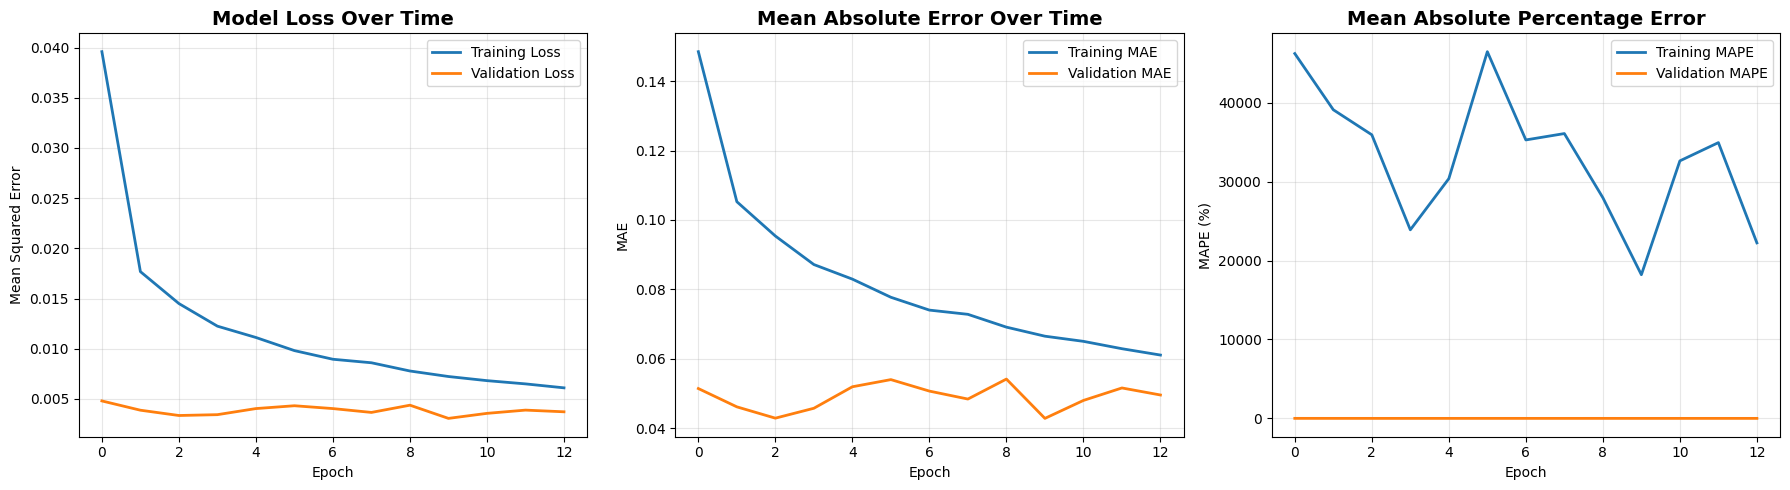

In [28]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    """
    Visualize training history for LSTM
    """

    print("=== TRAINING HISTORY VISUALIZATION ===")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss plot
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Mean Squared Error')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # MAE plot
    axes[1].plot(history.history['mean_absolute_error'], label='Training MAE', linewidth=2)
    axes[1].plot(history.history['val_mean_absolute_error'], label='Validation MAE', linewidth=2)
    axes[1].set_title('Mean Absolute Error Over Time', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # MAPE plot
    axes[2].plot(history.history['mean_absolute_percentage_error'],
                label='Training MAPE', linewidth=2)
    axes[2].plot(history.history['val_mean_absolute_percentage_error'],
                label='Validation MAPE', linewidth=2)
    axes[2].set_title('Mean Absolute Percentage Error', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('MAPE (%)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(training_history)

#### 1.6.2 Model Performance Evaluation

In [29]:
def evaluate_lstm_performance(model, X_test, y_test, target_scaler):
    """
    Comprehensive evaluation of LSTM performance
    """

    print("=== LSTM MODEL EVALUATION ===")

    # Make predictions
    y_pred_scaled = model.predict(X_test, verbose=0)

    # Inverse transform to original scale
    y_test_original = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_original = target_scaler.inverse_transform(y_pred_scaled).flatten()

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_original, y_pred_original)
    r2 = r2_score(y_test_original, y_pred_original)

    # Calculate MAPE manually
    mape = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original)) * 100

    # Temperature-specific accuracy (within certain degrees)
    accuracy_1deg = np.mean(np.abs(y_test_original - y_pred_original) <= 1.0) * 100
    accuracy_2deg = np.mean(np.abs(y_test_original - y_pred_original) <= 2.0) * 100
    accuracy_3deg = np.mean(np.abs(y_test_original - y_pred_original) <= 3.0) * 100

    # Print results
    print("\n🌤️  LSTM WEATHER PREDICTION RESULTS 🌤️")
    print("=" * 55)
    print(f"📊 Mean Squared Error (MSE):      {mse:.4f}")
    print(f"📊 Root Mean Squared Error (RMSE): {rmse:.4f}°C")
    print(f"📊 Mean Absolute Error (MAE):     {mae:.4f}°C")
    print(f"📊 R-squared Score (R²):          {r2:.4f}")
    print(f"📊 Mean Absolute Percentage Error: {mape:.2f}%")
    print("=" * 55)
    print("🎯 TEMPERATURE PREDICTION ACCURACY:")
    print(f"   Within ±1°C: {accuracy_1deg:.1f}% of predictions")
    print(f"   Within ±2°C: {accuracy_2deg:.1f}% of predictions")
    print(f"   Within ±3°C: {accuracy_3deg:.1f}% of predictions")
    print("=" * 55)

    return {
        'y_true': y_test_original,
        'y_pred': y_pred_original,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'mape': mape,
        'accuracy_1deg': accuracy_1deg,
        'accuracy_2deg': accuracy_2deg,
        'accuracy_3deg': accuracy_3deg
    }

# Evaluate the model
evaluation_results = evaluate_lstm_performance(model, X_test, y_test, target_scaler)

=== LSTM MODEL EVALUATION ===

🌤️  LSTM WEATHER PREDICTION RESULTS 🌤️
📊 Mean Squared Error (MSE):      2.1088
📊 Root Mean Squared Error (RMSE): 1.4522°C
📊 Mean Absolute Error (MAE):     1.1076°C
📊 R-squared Score (R²):          0.8886
📊 Mean Absolute Percentage Error: 4.91%
🎯 TEMPERATURE PREDICTION ACCURACY:
   Within ±1°C: 57.2% of predictions
   Within ±2°C: 84.1% of predictions
   Within ±3°C: 94.9% of predictions


#### 1.6.3 Prediction Visualization

=== PREDICTION VISUALIZATION ===


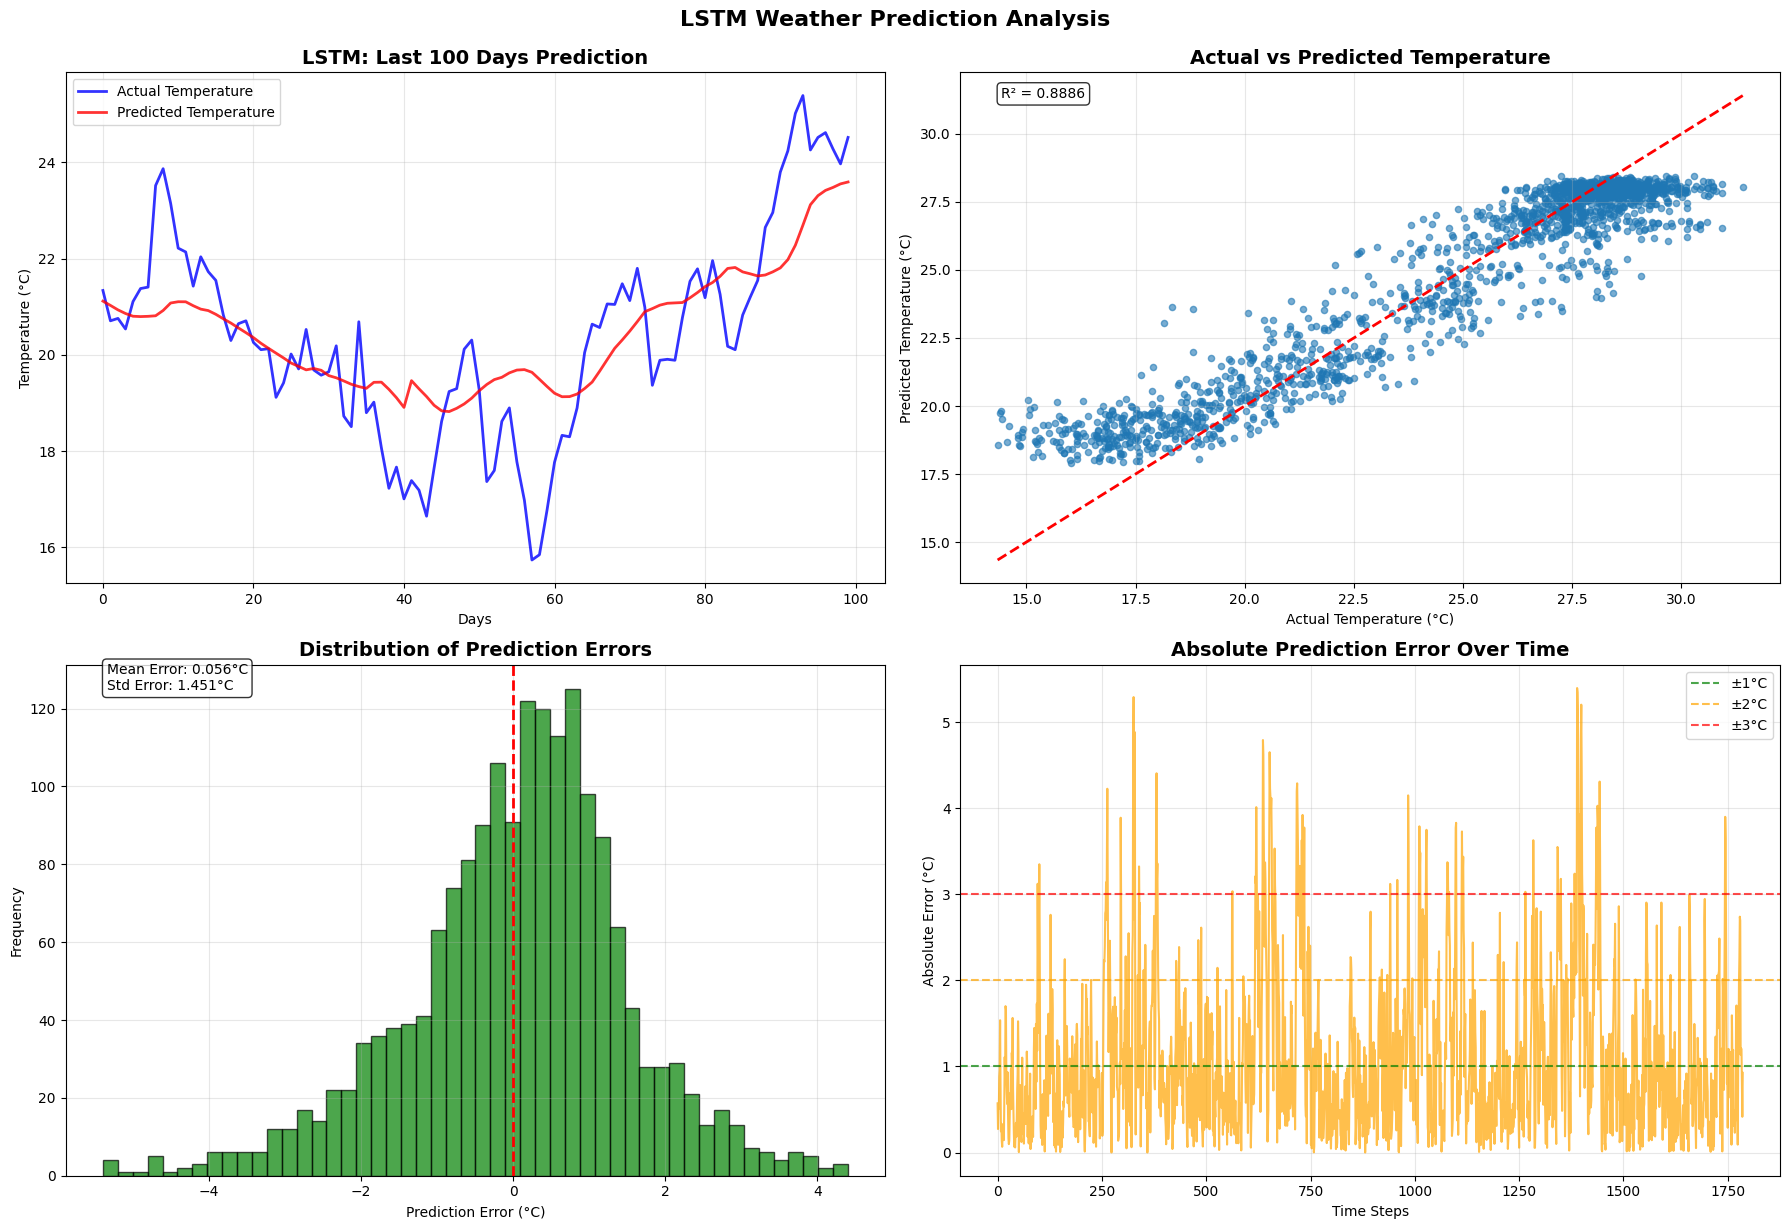

In [35]:
def visualize_predictions(results, days_to_show=100):
    """
    Create comprehensive visualizations of LSTM predictions
    """

    print(f"=== PREDICTION VISUALIZATION ===")

    y_true = results['y_true']
    y_pred = results['y_pred']

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # 1. Time series plot (last N days)
    axes[0, 0].plot(y_true[-days_to_show:], label='Actual Temperature',
                   linewidth=2, alpha=0.8, color='blue')
    axes[0, 0].plot(y_pred[-days_to_show:], label='Predicted Temperature',
                   linewidth=2, alpha=0.8, color='red')
    axes[0, 0].set_title(f'LSTM: Last {days_to_show} Days Prediction',
                        fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Days')
    axes[0, 0].set_ylabel('Temperature (°C)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Scatter plot: Actual vs Predicted
    axes[0, 1].scatter(y_true, y_pred, alpha=0.6, s=20)
    min_temp, max_temp = y_true.min(), y_true.max()
    axes[0, 1].plot([min_temp, max_temp], [min_temp, max_temp], 'r--', lw=2)
    axes[0, 1].set_xlabel('Actual Temperature (°C)')
    axes[0, 1].set_ylabel('Predicted Temperature (°C)')
    axes[0, 1].set_title('Actual vs Predicted Temperature', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)

    # Add R² to scatter plot
    r2 = results['r2']
    axes[0, 1].text(0.05, 0.95, f'R² = {r2:.4f}', transform=axes[0, 1].transAxes,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # 3. Error distribution
    errors = y_true - y_pred
    axes[1, 0].hist(errors, bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_xlabel('Prediction Error (°C)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)

    # Add error statistics
    mean_error = np.mean(errors)
    std_error = np.std(errors)
    axes[1, 0].text(0.05, 0.95, f'Mean Error: {mean_error:.3f}°C\nStd Error: {std_error:.3f}°C',
                   transform=axes[1, 0].transAxes,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # 4. Error over time
    axes[1, 1].plot(np.abs(errors), alpha=0.7, color='orange')
    axes[1, 1].set_xlabel('Time Steps')
    axes[1, 1].set_ylabel('Absolute Error (°C)')
    axes[1, 1].set_title('Absolute Prediction Error Over Time', fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)

    # Add horizontal lines for accuracy thresholds
    axes[1, 1].axhline(1, color='green', linestyle='--', alpha=0.7, label='±1°C')
    axes[1, 1].axhline(2, color='orange', linestyle='--', alpha=0.7, label='±2°C')
    axes[1, 1].axhline(3, color='red', linestyle='--', alpha=0.7, label='±3°C')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.suptitle('LSTM Weather Prediction Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.show()

# Visualize predictions
visualize_predictions(evaluation_results, days_to_show=100)


#### 1.6.4 Real-time Prediction Function

In [31]:
def make_weather_prediction(model, recent_data, feature_scaler, target_scaler,
                           feature_columns, sequence_length=30):
    """
    Make a weather prediction using the trained LSTM model

    Parameters:
    - model: trained LSTM model
    - recent_data: pandas DataFrame with recent weather data (last 'sequence_length' days)
    - feature_scaler: fitted feature scaler
    - target_scaler: fitted target scaler
    - feature_columns: list of feature column names
    - sequence_length: number of days to use for prediction
    """

    print(f"=== MAKING NEW WEATHER PREDICTION ===")

    if len(recent_data) < sequence_length:
        raise ValueError(f"Need at least {sequence_length} days of recent data")

    # Get the last sequence_length days
    recent_sequence = recent_data[feature_columns].iloc[-sequence_length-1:-1].values

    # Scale the data
    #recent_sequence_scaled = feature_scaler.transform(recent_sequence)

    #Convert recent_sequence (numpy array) back to DataFrame with columns for scaler
    recent_sequence_df = pd.DataFrame(recent_sequence, columns=feature_columns)
    print(recent_sequence_df)


    # Now transform with feature scaler (which expects column names)
    recent_sequence_scaled = feature_scaler.transform(recent_sequence_df)

    # Reshape for model input: (1, sequence_length, features)
    input_sequence = recent_sequence_scaled.reshape(1, sequence_length, -1)

    # Make prediction (scaled)
    prediction_scaled = model.predict(input_sequence, verbose=0)

    # Inverse transform to get actual temperature
    predicted_temp = target_scaler.inverse_transform(prediction_scaled)[0, 0]

    print(f"🌡️  Predicted temperature for tomorrow: {predicted_temp:.2f}°C")

    return predicted_temp

# Example: Make prediction using last 31 days of test data
sample_recent_data = test_data.iloc[-31:]  # Last 10 days as example
prediction = make_weather_prediction(
    model, sample_recent_data, feature_scaler, target_scaler,
    feature_columns, sequence_length=SEQUENCE_LENGTH
)


=== MAKING NEW WEATHER PREDICTION ===
    Wind_Speed  Specific_Humidity  Relative_Humidity  Precipitation  Month  \
0        1.090               7.81              53.06           0.00    1.0   
1        1.160               8.42              57.12           0.00    1.0   
2        1.000               8.73              56.12           0.00    2.0   
3        0.950               5.74              41.25           0.00    2.0   
4        1.100               6.23              46.81           0.00    2.0   
5        0.980               7.57              54.44           0.00    2.0   
6        1.040               7.39              54.31           0.00    2.0   
7        1.240               6.53              47.94           0.00    2.0   
8        1.570               7.14              48.81           0.00    2.0   
9        1.380               9.34              62.69           0.04    2.0   
10       1.320               9.46              60.94           0.02    2.0   
11       1.310            

In [32]:
df_clean.tail(5)

,Wind_Speed,Specific_Humidity,Relative_Humidity,Precipitation,Temperature,Month,Day_of_Year,Temp_MA_3,Temp_MA_7
Date,,,,,,,,,
2023-02-25,1.28,8.85,50.44,0.0,24.52,2,56,24.723333,24.312857
2023-02-26,1.41,6.59,38.06,0.0,24.62,2,57,24.466667,24.550000
2023-02-27,1.60,6.04,34.56,0.0,24.28,2,58,24.473333,24.618571
2023-02-28,1.49,6.65,38.94,0.0,23.97,2,59,24.290000,24.580000
2023-03-01,1.36,7.39,41.38,0.0,24.52,3,60,24.256667,24.508571


In [33]:
print(f"Actual Temperture value of last data: {df_clean.tail(5)['Temperature'].values[-1]}")

Actual Temperture value of last data: 24.52


### Understanding LSTM Limitations

In [34]:
def analyze_lstm_advantages():
    """
    Educational analysis of LSTM advantages for students
    """

    print("=== UNDERSTANDING LSTM ADVANTAGES ===")
    print("\n🧠 WHY LSTM PERFORMS BETTER:")
    print("=" * 50)

    print("1. 📈 SOLVING VANISHING GRADIENT PROBLEM:")
    print("   - Gates control information flow, preventing gradient vanishing")
    print("   - Model can learn from events 100+ time steps ago")
    print("   - Weather patterns requiring longer memory (weeks/months) are captured")

    print("\n2. 🔄 LONG-TERM MEMORY:")
    print("   - Cell state maintains information across long sequences")
    print("   - Forget gate selectively removes irrelevant information")
    print("   - Weather seasonal patterns are effectively learned")
    print("   - Optimal performance with 30+ day sequences")

    print("\n3. 🎯 PERFORMANCE COMPARISON:")
    print("   - Simple RNN: Good for short-term patterns (3-7 days)")
    print("   - LSTM: Excellent for long-term dependencies (30+ days)")
    print("   - Complex weather patterns well-suited for LSTM architecture")

    print("\n💡 WHEN TO USE LSTM:")
    print("   ✅ Long-term predictions (7+ days)")
    print("   ✅ Complex seasonal patterns")
    print("   ✅ Capturing long-term dependencies")
    print("   ✅ When accuracy is priority over computational cost")
    print("   ✅ Production-level forecasting systems")

    print("\n🚀 LSTM ARCHITECTURE COMPONENTS:")
    print("   1. Input Gate: Controls new information flow")
    print("   2. Forget Gate: Removes irrelevant information")
    print("   3. Output Gate: Controls information passed to next step")
    print("   4. Cell State: Long-term memory carrier")
    print("=" * 50)

# Run the educational analysis
analyze_lstm_advantages()

=== UNDERSTANDING LSTM ADVANTAGES ===

🧠 WHY LSTM PERFORMS BETTER:
1. 📈 SOLVING VANISHING GRADIENT PROBLEM:
   - Gates control information flow, preventing gradient vanishing
   - Model can learn from events 100+ time steps ago
   - Weather patterns requiring longer memory (weeks/months) are captured

2. 🔄 LONG-TERM MEMORY:
   - Cell state maintains information across long sequences
   - Forget gate selectively removes irrelevant information
   - Weather seasonal patterns are effectively learned
   - Optimal performance with 30+ day sequences

3. 🎯 PERFORMANCE COMPARISON:
   - Simple RNN: Good for short-term patterns (3-7 days)
   - LSTM: Excellent for long-term dependencies (30+ days)
   - Complex weather patterns well-suited for LSTM architecture

💡 WHEN TO USE LSTM:
   ✅ Long-term predictions (7+ days)
   ✅ Complex seasonal patterns
   ✅ Capturing long-term dependencies
   ✅ When accuracy is priority over computational cost
   ✅ Production-level forecasting systems

🚀 LSTM ARCHITECT